# 03 — Modelo Principal: Bagging — Random Forest
Predicción Won (1) vs Lost (0) — CRM Sales Opportunities

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, roc_auc_score, RocCurveDisplay
)
from paths import PROCESSED_DIR

X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DIR / "X_test.csv")
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv").squeeze()
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv").squeeze()

## Entrenamiento del modelo

Aquí **entrenamos** el Random Forest: el algoritmo del tema **Bagging**.

**¿Qué estamos haciendo?**  
Le mostramos al modelo ejemplos de oportunidades de venta que ya terminaron en **Won** o **Lost**, para que aprenda qué características suelen llevar a ganar o perder un deal (sector, producto, agente, ingresos de la empresa, etc.).

**¿Cómo funciona Bagging?**  
En lugar de un solo árbol de decisión, se entrenan **200 árboles** con muestras distintas de los datos. Al final, todos **votan** y gana la clase con más votos: Won o Lost.

**Datos que usamos**
- `X_train` → información de cada oportunidad (variables del CRM ya limpias)
- `y_train` → resultado real: 1 = Won, 0 = Lost


Después probamos qué tan bien aprendió con datos que **no vio** (`X_test`): accuracy, F1, matriz de confusión y curva ROC.

Usamos X_train sin escalar
Random Forest divide por umbrales, no importa si el número es grande o pequeño en escala absoluta.

In [2]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    max_features="sqrt",
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 macro : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_proba):.4f}")
print(classification_report(y_test, y_pred, target_names=["Lost", "Won"]))

Accuracy : 0.5101
F1 macro : 0.5047
AUC-ROC  : 0.5179
              precision    recall  f1-score   support

        Lost       0.39      0.55      0.45       495
         Won       0.65      0.49      0.56       848

    accuracy                           0.51      1343
   macro avg       0.52      0.52      0.50      1343
weighted avg       0.55      0.51      0.52      1343



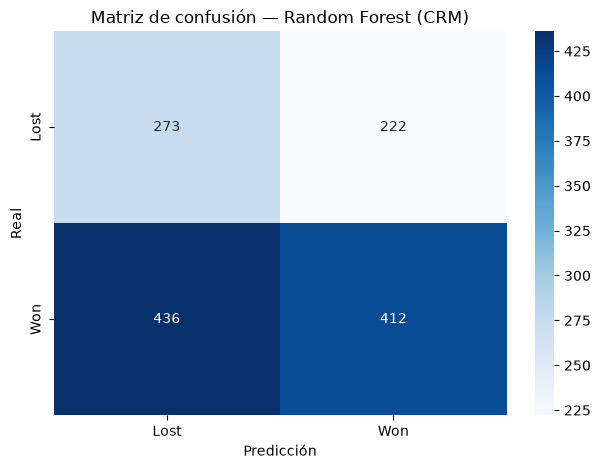

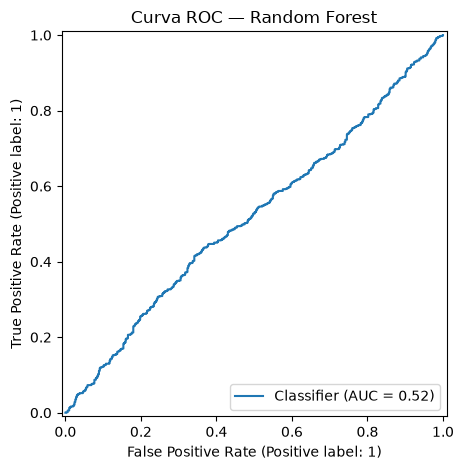

In [3]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Lost", "Won"], yticklabels=["Lost", "Won"])
plt.title("Matriz de confusión — Random Forest (CRM)")
plt.ylabel("Real"); plt.xlabel("Predicción")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Curva ROC — Random Forest")
plt.tight_layout()
plt.show()

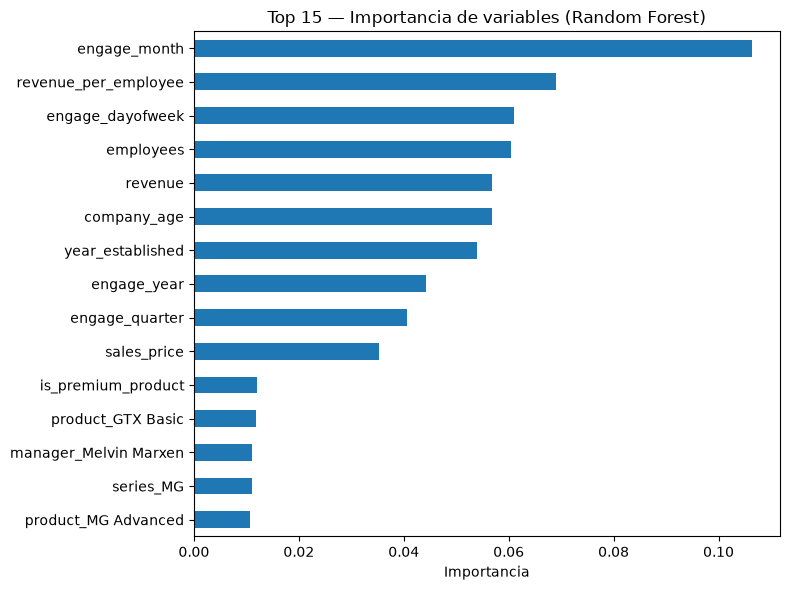

Modelo guardado en: D:\UNIVALLE\GESTION 1-2026 ISI\TECN.EMERG.I\ASSIGNMENT\2026.06.14 TI26 - Proyecto + Exposición Final\REPOSITORIO-TI26-TEAM-Heredia-Illanes\data\processed\rf_model.joblib


In [4]:
importance = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=True).tail(15).plot(kind="barh", figsize=(8, 6))
plt.title("Top 15 — Importancia de variables (Random Forest)")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

joblib.dump(rf_model, PROCESSED_DIR / "rf_model.joblib")
print("Modelo guardado en:", PROCESSED_DIR / "rf_model.joblib")